# Zaawansowana Analiza i Optymalizacja Portfela Inwestycyjnego

Niniejszy notatnik przedstawia kompletny, ilościowy (quantitative) proces budowy i oceny portfela akcyjnego. Przechodzimy w nim pełną ścieżkę – od surowych danych rynkowych, przez diagnozę ryzyka, aż po zaawansowaną optymalizację matematyczną.

### Przekrój projektu:

1. **Inżynieria Danych:** Pobranie historycznych cen z Yahoo Finance i transformacja do logarytmicznych stóp zwrotu.
2. **Model CAPM (Wycena Aktywów):** Dekompozycja ryzyka na systematyczne (Beta) i specyficzne oraz poszukiwanie rynkowej "Alphy" przy użyciu regresji liniowej.
3. **Analiza Ryzyka Skrajnego (Tail Risk):** Symulacja historyczna wskaźników VaR (Value at Risk) oraz CVaR (Conditional Value at Risk) w celu diagnozy "grubych ogonów".
4. **Optymalizacja Markowitza (MPT):** Wykorzystanie programowania kwadratowego (`scipy.optimize`) do znalezienia portfela Global Minimum Variance (GMV), optymalizacja Mean-Variance dla zadanego celu oraz wizualizacja Granicy Efektywnej (Efficient Frontier).

# Etap 1 - Wczytanie danych
Będziemy korzystać i operować na giełdzie amerykańskiej. W tym celu będziemy potrzebować ściągnąć historyczne dane amerykańskich spółek. W tym celu użyjemy yfinance

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Wybieramy tickery: 3 spółki Tech, 2 Defensywne i Rynek (S&P 500)
tickers = ['AAPL', 'MSFT', 'NVDA', 'KO', 'JNJ', '^GSPC']

# Pobieramy dane z ostatnich 5 lat
data = yf.download(tickers, start="2021-01-01", end="2026-03-06", interval="1d")['Close']

# Zobaczmy, co pobraliśmy
data.tail()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,JNJ,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2026-02-27,264.179993,248.429993,81.559998,392.739990,177.190002,6878.879883
2026-03-02,264.720001,248.559998,80.220001,398.549988,182.479996,6881.620117
2026-03-03,263.750000,246.750000,79.339996,403.929993,180.050003,6816.629883
2026-03-04,262.519989,245.300003,78.099998,405.200012,183.039993,6869.500000
2026-03-05,260.290009,239.630005,77.029999,410.679993,183.339996,6830.709961


W modelu musimy założyć chociażby słabą stacjonarność (stacjonarność z przesuwanymi oknami) zwrotów (uzyskamy ją przez Log-Zwroty) tak aby $\mathbb{E}[P_i]$ = $\mathbb{E}[P_k]$, dla $ i \not= k $. Takie założenie pozwoli nam skorzystać z Praw Wielkich Liczb do estymacji stopy zwrotu $\mathbb{E}[\mu]$. Bez tego liczylibyśmy średnią arytmetyczną np okresu covidowego i boom-u pocovidowego co dałoby jakąś liczbę, ale byłaby ona marnym odzwierciedleniem rynku

In [2]:
#Wprowadźmy zatem Log-Zwroty
log_returns = np.log(data/data.shift(1)).round(5)
log_returns = log_returns.dropna()
log_returns

Ticker,AAPL,JNJ,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-01-05,0.01229,0.01169,-0.01105,0.00096,0.02197,0.00706
2021-01-06,-0.03424,0.00937,-0.03233,-0.02627,-0.06076,0.00569
2021-01-07,0.03355,0.00337,-0.01115,0.02806,0.05622,0.01474
2021-01-08,0.00859,-0.00206,0.02217,0.00607,-0.00505,0.00548
2021-01-11,-0.02352,-0.00420,-0.01738,-0.00975,0.02564,-0.00658
...,...,...,...,...,...,...
2026-02-27,-0.03266,0.02017,0.01308,-0.02261,-0.04254,-0.00435
2026-03-02,0.00204,0.00052,-0.01657,0.01469,0.02942,0.00040
2026-03-03,-0.00367,-0.00731,-0.01103,0.01341,-0.01341,-0.00949


Mając już stacjonarne zmienne losowe (ceny na zamknięcie), możemy przystąpić do zbadania korelacji między spółkami. W tym celu wyliczymy macierz kowariancji i korelacji. Niech $T$ będzie oznaczać liczbe obserwacji $n$ spółek w naszym portfolio. Niech $R_i$ będzie zmienną losową reprezentującą log-zwrot akcji $i$, a $R_{i,t}$ jej realizacją w dniu $t$.

Dla każdej zmiennej losowej $R_i$ najpierw wyznaczamy średnią arytmetyczną (jako estymator jej prawdziwej wartości oczekiwanej $\mu_i$):$$\hat{\mu}_i = \frac{1}{T} \sum_{t=1}^{T} R_{i,t}$$

Z definicji teoretycznej $Cov(X,Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])]$. Ponieważ pracujemy na próbie historycznej, używamy nieobciążonego estymatora kowariancji dla dwóch dowolnych akcji $i$ oraz $j$:$$\hat{\sigma}_{i,j} = \frac{1}{T-1} \sum_{t=1}^{T} (R_{i,t} - \hat{\mu}_i)(R_{j,t} - \hat{\mu}_j)$$

In [3]:
mean = log_returns.mean().round(7)
cov = log_returns.cov()


Mając już policzoną zarówno Macierz Kowariancji jak i wyestymowaną średnią, możemy przystąpić do do policzenia macierzy korelacji. Sama kowariancja jest trudna do interpretacji, bo zależy od "wielkości" wahań. Dlatego normalizujemy ją, dzieląc przez iloczyn odchyleń standardowych. Współczynnik korelacji to:$$\rho_{i,j} = \frac{\hat{\sigma}_{i,j}}{\hat{\sigma}_i \hat{\sigma}_j}$$Gdzie odchylenie standardowe to $\hat{\sigma}_i = \sqrt{\hat{\sigma}_{i,i}}$. Wynik zawsze zamyka się w przedziale $[-1, 1]$. 

In [4]:
corr = log_returns.corr().round(7)
corr

Ticker,AAPL,JNJ,KO,MSFT,NVDA,^GSPC
Ticker,,,,,,
AAPL,1.000000,0.150288,0.265152,0.601913,0.513942,0.749331
JNJ,0.150288,1.000000,0.444494,0.060220,-0.096662,0.210772
KO,0.265152,0.444494,1.000000,0.175868,0.004617,0.328865
MSFT,0.601913,0.060220,0.175868,1.000000,0.612873,0.739165
NVDA,0.513942,-0.096662,0.004617,0.612873,1.000000,0.705044
^GSPC,0.749331,0.210772,0.328865,0.739165,0.705044,1.000000


Zwizualizujmy sobie ją za pomocą Mapy Ciepła (heatmap).

<Axes: xlabel='Ticker', ylabel='Ticker'>

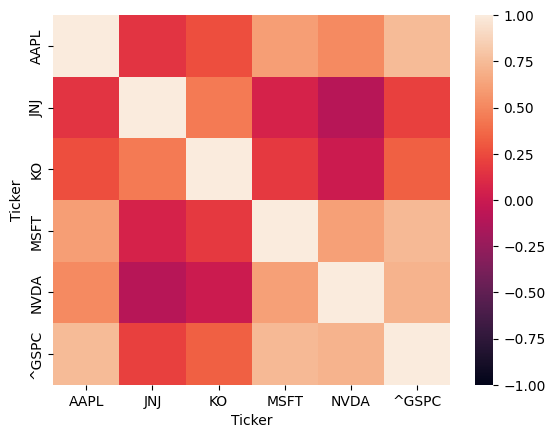

In [5]:
sns.heatmap(corr, vmin=-1, vmax=1)

Nietrudno dostrzec zatem zależność że spólki technologiczne są ze sobą pozytywnie skorelowane (ten sam sektor) jak i pozytywnie skorelowane są z rynkiem, co sugeruje że performance rynku jest silnie uzależniony od sytuacji spółek technologicznych. W pozostalych przypadkach korelacja nie jest tak wyraźnie zarysowana.

In [6]:
stocks_returns = log_returns.iloc[:, :-1]
market_returns = log_returns.iloc[:, -1]

# CAPM - Capital Assets Pricing Model
Mając już wprowadzone log-zwroty, możemy przystąpić do badania Bety. W tym celu skorzystamy z modelu CAPM.
W modelu CAPM naszą zmienną "wyjaśniającą" jest zwrot z całego rynku (indeksu), oznaczmy go jako zmienną losową $R_m$. Chcemy zmierzyć wrażliwość naszej konkretnej akcji $R_i$ na zachowanie rynku.

### Definicja i Regresja Liniowa
Beta ($\beta_i$) to matematycznie współczynnik kierunkowy w równaniu prostej regresji liniowej. Równanie to wygląda tak:$$R_{i,t} = \alpha_i + \beta_i R_{m,t} + \epsilon_{i,t}$$Gdzie:
- $\alpha_i$ to stała (wyraz wolny, czyli tzw. "Alpha" – nadwyżkowy zysk).
- $\beta_i$ to nasza szukana Beta.
- $\epsilon_{i,t}$ to składnik resztowy (szum/błąd). 
Zakładamy, że ma wartość oczekiwaną zero ($\mathbb{E}[\epsilon] = 0$) oraz jest całkowicie nieskorelowany z rynkiem, czyli $Cov(\epsilon_i, R_m) = 0$.

wzór na Betę akcji w modelu CAPM to:
$$\beta_i = \frac{Cov(R_i, R_m)}{Var(R_m)}$$
Używając naszych estymatorów wyliczonych powyżej, liczymy to na danych historycznych po prostu jako:
$$\hat{\beta}_i = \frac{\hat{\sigma}_{i,m}}{\hat{\sigma}_{m,m}}$$

In [7]:
#Policzymy Bety od razu dla wszystkich spółek na raz
def calculate_betas(stock,market):
    betas = {}
    
    #Wariancja rynku
    market_variance = market.var(ddof=1) #ddof=1 to dzielenie przez T-1
    
    for col in stock.columns:
        # Liczymy kowariancję między daną spółką a rynkiem (licznik)
        # np.cov zwraca macierz 2x2, kowariancja jest pod indeksem [0, 1]
        stock_covariance = np.cov(stock[col], market)[0,1]
        # Wzór na Betę: Cov(Akcja, Rynek) / Var(Rynek)
        beta = stock_covariance / market_variance
        betas[col] = beta
    
    return pd.Series(betas, name="Beta CAPM")

betas_table = calculate_betas(stocks_returns, market_returns)
print(betas_table)


AAPL    1.237010
JNJ     0.210217
KO      0.312480
MSFT    1.151540
NVDA    2.157052
Name: Beta CAPM, dtype: float64


Otrzymaliśmy zatem nasze Bety. Spółki z Betami = 1 poruszają się zgodnie z rynkiem, dla Bety < 1 spółki reagują słabiej niż rynek (wolniej rosną i wolniej spadają) a dla Bety > 1 spółki rosną szybciej niż rynek ale za to szybciej spadają

## Dekompozycja Ryzyka

W tym kroku przeprowadzamy regresję liniową (Metodą Najmniejszych Kwadratów) dla każdej spółki względem rynku (S&P 500). 

##### Po co to robimy?
Chcemy zrozumieć, z jakich "klocków ryzyka" zbudowane są nasze akcje. Model CAPM pozwala nam oddzielić to, co zależy od koniunktury na świecie, od tego, co jest unikalne dla danej firmy. 

##### Co otrzymujemy i jak to interpretować?

1. Beta ($\beta$): Mierzy agresywność i wrażliwość na rynek.
   * $\beta = 1$: Spółka porusza się identycznie jak rynek.
   * $\beta > 1$: Spółka agresywna (np. 1.5 oznacza, że rośnie/spada 1.5 raza mocniej niż rynek).
   * $\beta < 1$: Spółka defensywna (bezpieczna przystań w czasie krachu).
2. Alpha ($\alpha$): Teoretyczny, nadwyżkowy zysk roczny. Jeśli jest dodatni, spółka "bije" rynek.
3. Ryzyko Rynkowe ($R^2$): Procent zmienności akcji, który jest wywołany ruchami całego rynku (ryzyko systematyczne, którego nie da się zdywersyfikować).
4. Ryzyko Specyficzne ($1 - R^2$): Procent zmienności wynikający z unikalnych cech spółki (np. premiery produktów, decyzje zarządu). To ryzyko możemy zminimalizować poprzez dodanie innych, nieskorelowanych spółek do portfela.

In [8]:
from scipy import stats

def calculate_capm_regression(stocks, market):
    results = {}
    
    for column in stocks.columns:
        # Odpalamy pełną regresję liniową: X = rynek, Y = spółka
        lin_reg = stats.linregress(market, stocks[column])
        
        # Wyciągamy statystyki z modelu
        beta = lin_reg.slope            # Współczynnik kierunkowy
        alpha = lin_reg.intercept       # Wyraz wolny (przecięcie z osią Y)
        r_squared = lin_reg.rvalue ** 2 # Współczynnik determinacji (R^2)
        
        # Zapisujemy wyniki. Alphę mnożymy przez 252 (liczba dni sesyjnych), żeby mieć wynik roczny
        results[column] = {
            'Beta CAPM': round(beta, 2),
            'Alpha (Roczna %)': round(alpha * 252 * 100, 2),
            'Ryzyko Rynkowe R^2 (%)': round(r_squared * 100, 2),
            'Ryzyko Specyficzne (%)': round((1 - r_squared) * 100, 2)
        }
        
    # Zamieniamy słownik na df i ją transponujemy (.T) dla lepszej czytelności
    return pd.DataFrame(results).T

capm_diagnostics = calculate_capm_regression(stocks_returns, market_returns)
capm_diagnostics

,Beta CAPM,Alpha (Roczna %),Ryzyko Rynkowe R^2 (%),Ryzyko Specyficzne (%)
AAPL,1.24,-0.61,56.15,43.85
JNJ,0.21,8.64,4.44,95.56
KO,0.31,6.55,10.82,89.18
MSFT,1.15,-0.54,54.64,45.36
NVDA,2.16,25.61,49.71,50.29


Otrzymaliśmy za tem z tego modelu sporo liczb, jakie można wyciągnąć z tego wnioski?
- Nvidia dzięki boomowi na AI rosła nieprawdopodobnie dynamicznie, stąd tak ogromna Alpha
- spólki technologiczne są naprawde zależne od rynku (poziom $R^2$ na poziomie 50%), co tylko potwierdza skorelowanie z rynkiem

Jest jednak w tym wszystkim problem, konkretnie problem z założeniami. W modelu CAPM zakładaliśmy że zwroty mają rozkład normalny. To jednak nie jest prawdą i niesie za sobą bardzo poważne konsekwencje, ponieważ wg tego rozkładu zdarzenia skrajne mają minimalne prawdopodobieństwo wystąpienia co bardzo zaburza poprawną ocene portfolio. Ponieważ zwroty charakteryzują się rozkładem z grubymi ogonami, trzeba będzie o tą informacje jakoś skorygować naszą analizę. W tym celu posłuzymy się **VaR** i **CVaR**.

## Test Zderzeniowy – Analiza Ryzyka Skrajnego (VaR i CVaR)

### Problem "Grubych Ogonów"
W poprzednim kroku, korzystając z modelu CAPM (opartego na regresji liniowej), milcząco zakładaliśmy, że stopy zwrotu podlegają rozkładowi normalnemu. W rzeczywistości rynkowej jest to założenie błędne. Empiryczne stopy zwrotu charakteryzują się tzw. **grubymi ogonami (fat tails)** oraz wykazują zjawisko grupowania zmienności (heteroskedastyczność). Oznacza to, że skrajne krachy zdarzają się znacznie częściej, niż przewiduje to rozkład Gaussa. 

Aby rzetelnie ocenić ryzyko portfela i nie zignorować ryzyka katastrof, wprowadzamy dwie miary ryzyka oparte na empirycznym rozkładzie strat: **Value at Risk (VaR)** oraz **Conditional Value at Risk (CVaR)**.

Na potrzeby formalizmu definiujemy zmienną losową $L = -R$ (gdzie $R$ to log-zwrot), reprezentującą stratę z inwestycji, oraz poziom ufności $\alpha \in (0, 1)$ (w naszej analizie przyjmujemy standardowe $\alpha = 0.95$).

---

### 1. Value at Risk (VaR) – Próg Bólu
VaR odpowiada na pytanie: *"Jaka jest maksymalna strata, której nie przekroczymy w danym dniu z prawdopodobieństwem 95%?"*. Jest to po prostu kwantyl rzędu $\alpha$ z rozkładu strat.

**Definicja formalna:**
Szukamy najmniejszej wartości straty $l$, dla której prawdopodobieństwo, że nasza faktyczna strata $L$ będzie mniejsza lub równa $l$, wynosi dokładnie $\alpha$:
$$VaR_\alpha(L) = \inf \{ l \in \mathbb{R} : P(L \le l) \ge \alpha \}$$

**Ograniczenia VaR:**
Choć VaR jest standardem rynkowym, ma dwie poważne wady matematyczne:
1. Nie mówi nam absolutnie nic o tym, co dzieje się w najgorszych 5% przypadków (jak duża będzie strata, gdy już przekroczymy próg).
2. Nie jest dobrą miarą ryzyka (nie spełnia aksjomatu subaddytywności), co oznacza, że w specyficznych przypadkach VaR może karać za dywersyfikację.

---

### 2. Conditional Value at Risk (CVaR / Expected Shortfall) – Analiza Ogona
Aby rozwiązać problemy miary VaR, wprowadzamy CVaR. Odpowiada on na pytanie: *"Jeśli już dojdzie do najgorszego (strata przekroczy VaR), to ile średnio wyniesie ta skrajna strata?"*. 

**Definicja formalna:**
CVaR to warunkowa wartość oczekiwana straty, pod warunkiem, że strata ta jest ściśle większa od wyznaczonego wcześniej progu VaR:
$$CVaR_\alpha(L) = \mathbb{E}[L \mid L > VaR_\alpha(L)]$$

Dla rozkładów ciągłych o gęstości $f_L(l)$, zapisujemy to jako całkę w ogonie rozkładu:
$$CVaR_\alpha(L) = \frac{1}{1-\alpha} \int_{VaR_\alpha}^{\infty} l \cdot f_L(l) dl$$

CVaR bezwzględnie promuje dywersyfikację i uwzględnia cały kształt grubego ogona.

---

### Metodologia: Symulacja Historyczna
Ponieważ odrzucamy rozkład normalny, do estymacji tych miar użyjemy  **Symulacji Historycznej**. Zamiast liczyć wariancje i średnie, zbudujemy dystrybuantę empiryczną: posortujemy historyczne dzienne stopy zwrotu od najgorszych do najlepszych, a następnie odetniemy 5% najgorszych obserwacji, aby wyznaczyć punkt odcięcia (VaR) oraz ich średnią wartość (CVaR).

In [9]:
# Funkcja wyliczająca historyczny VaR i CVaR
def calculate_historical_risk(returns, alpha=0.05):
    results = {}
    
    for column in returns.columns:
        stock_rets = returns[column]
        
        #VaR: Szukamy kwantyla 5% (odcina 5% najgorszych dziennych stóp zwrotu)
        var = stock_rets.quantile(alpha)
        
        #CVaR: Filtrujemy tylko te zwroty, które są GORSZE od VaR, i wyciągamy z nich średnią
        cvar = stock_rets[stock_rets <= var].mean()
        
        # Zapisujemy wyniki. Mnożymy przez 100, żeby mieć ładne procenty,
        results[column] = {
            f'VaR ({(1-alpha)*100}%) w %': round(abs(var) * 100, 2),
            f'CVaR ({(1-alpha)*100}%) w %': round(abs(cvar) * 100, 2)
        }
        
    return pd.DataFrame(results).T

# Odpalamy na naszych zwrotach, alpha=0.05 oznacza poziom ufności 95%
risk_metrics = calculate_historical_risk(stocks_returns, alpha=0.05)
print(risk_metrics)

      VaR (95.0%) w %  CVaR (95.0%) w %
AAPL             2.89              3.99
JNJ              1.59              2.29
KO               1.55              2.22
MSFT             2.70              3.76
NVDA             4.92              6.96


### Wnioski z analizy ryzyka skrajnego (VaR i CVaR)

Powyższa tabela empirycznie weryfikuje zachowanie naszych spółek w momentach rynkowej paniki (najgorsze 5% dni sesyjnych). Z analizy płyną trzy kluczowe wnioski, które pokrywają się z wcześniejszą diagnozą modelu CAPM:

1. Kategoryzacja ryzyka spółek:
   * spółki defensywne (JNJ, KO): Charakteryzują się bardzo niskim ryzykiem skrajnym. Nawet po przekroczeniu "progu bólu" (VaR), ich średnia strata w czasie krachu (CVaR) wynosi zaledwie około 2.2% - 2.3% dziennie. Są to idealne stabilizatory portfela.
   * spólki rynkowe (AAPL, MSFT): Prezentują umiarkowane ryzyko technologiczne, z miarą CVaR na poziomie 3.8% - 4.0%, co odzwierciedla ich silne powiązanie z ogólnym nastrojem rynku.
   * ekstremalna zmienność (NVDA): Spółka o najwyższym ryzyku ogona. Jej VaR wynosi 4.92%, jednak w przypadku wystąpienia skrajnego scenariusza, średnia dzienna strata (CVaR) drastycznie rośnie aż do blisko 7%.

2. Dowód na istnienie "grubych ogonów":
   Wyraźny skok wartości między progiem VaR a średnią w ogonie CVaR (szczególnie w przypadku Nvidii, gdzie różnica to ponad 2 punkty procentowe) jest empirycznym dowodem na występowanie grubych ogonów. Udowadnia to, że skrajne załamania na giełdzie są głębsze i bardziej dotkliwe, niż zakładałaby to klasyczna statystyka oparta na rozkładzie normalnym.

3. Uzasadnienie dla optymalizacji portfela:
   Inwestowanie 100% kapitału w pojedyncze, agresywne akcje (jak NVDA) naraża inwestora na nieakceptowalne ryzyko kapitałowe (CVaR rzędu 7% dziennie). Aby zneutralizować to ryzyko specyficzne, niezbędne jest zastosowanie teorii portfelowej Markowitza, która dzięki wykorzystaniu braku idealnej korelacji między spółkami (dywersyfikacji) pozwoli znacząco obniżyć ryzyko całkowite.

## Optymalizacja Portfela – Model Markowitza (Mean-Variance) i GMV

W środowisku rynkowym inwestorzy mają różne apetyty na ryzyko. Zamiast narzucać im jeden sztywny portfel, wdrażamy pełen model optymalizacji Markowitza. Pozwala on na znalezienie **optymalnego portfela dla zadanego poziomu oczekiwanego zysku**. Innymi słowy, algorytm odpowiada na pytanie: *"Skoro wymagasz 20% rocznego zysku, to jak dobrać wagi spółek, aby to osiągnąć przy absolutnie najmniejszym możliwym ryzyku?"*. 

Zbiór wszystkich takich optymalnych portfeli dla różnych poziomów zysku tworzy tzw. **Granicę Efektywną (Efficient Frontier)**. Na samym dole tej krzywej znajduje się portfel **Global Minimum Variance (GMV)** – najbezpieczniejszy punkt na rynku, całkowicie ignorujący chęć maksymalizacji zysku na rzecz ochrony kapitału. 

### Formalizm Matematyczny
Niech $N$ oznacza liczbę ryzykownych aktywów, $w$ to wektor wag portfela, $\Sigma$ to roczna macierz kowariancji, a $\mu$ to wektor rocznych historycznych stóp zwrotu. 

Problem definiujemy następująco, gdzie minimalizujemy wariancję portfela $\sigma_p^2$:

$$\min_{w} \left( w^T \Sigma w \right)$$

Optymalizacja musi operować w ramach ograniczeń:
1. **Ograniczenie budżetowe:** Suma wag musi wynosić dokładnie 100% (kapitał jest w pełni alokowany).
   $$\sum_{i=1}^N w_i = 1$$
2. **Brak krótkiej sprzedaży (Long-only):** Wagi nie mogą być ujemne.
   $$w_i \ge 0 \quad \text{dla } i = 1, \dots, N$$
3. **Ograniczenie zysku (Target Return) - Opcjonalne:** Jeśli inwestor określi swój cel inwestycyjny $\mu_{target}$, algorytm wymusza, aby oczekiwany zysk portfela był mu równy:
   $$w^T \mu = \mu_{target}$$

Ponieważ w praktyce wyznaczenie rozwiązanie problemu przy podaniu $\mu_{target}$ jest często bardzo bardzo ciężkie i czasami nie generalizuje w przyszłość, można posłuzyć się **Global Minimum Variance (GMV)** co jest z reguły bezpieczniejszą, aczkolwiek mniej spektakularną opcją.

Do numerycznego rozwiązania tego wielowymiarowego problemu wykorzystujemy solver `scipy.optimize.minimize` z algorytmem **SLSQP (Sequential Least SQuares Programming)**, który iteracyjnie poszukuje globalnego minimum funkcji kwadratowej.

In [10]:
from scipy.optimize import minimize

def optimize_portfolio(returns, target_return=None):
    # Przygotowanie danych (mnożymy przez 252 dni sesyjne zeby miec roczne parametry)
    mu = returns.mean() * 252
    Sigma = returns.cov() * 252
    num_assets = len(returns.columns)
    
    # Nasza funkcja celu: Wariancja portfela (to chcemy zminimalizować)
    def portfolio_variance(weights):
        # Mnożenie macierzowe: w^T * Sigma * w
        return weights.T @ Sigma @ weights
        
    # unkt startowy (Równe wagi dla każdej spółki)
    init_guess = np.repeat(1 / num_assets, num_assets)
    
    # Ograniczenia (Constraints)
    # Podstawowe: wagi muszą sumować się do 1 (100%)    
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
    
    # Jeśli użytkownik podał cel zysku 
    if target_return is not None:
        # Dodajemy wymóg: w^T * mu = target_return
        constraints.append({'type': 'eq', 'fun': lambda x: np.sum(x * mu) - target_return})
        
    # 5. Granice (Bounds): każda waga od 0.0 do 1.0
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    
    # 6. Odpalamy numeryczny silnik SLSQP
    result = minimize(
        fun=portfolio_variance,
        x0=init_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    
    # Zwracamy ładnie sformatowane wagi w procentach
    return pd.Series(np.round(result.x * 100, 2), index=returns.columns, name="Wagi (%)")


#Test
# (Global Minimum Variance)
gmv_weights = optimize_portfolio(stocks_returns)
print("--- Portfel GMV (Maksymalne bezpieczeństwo) ---")
print(gmv_weights)
print("\n")

# 2. Portfel pod suwak użytkownika (Mean-Variance, cel: 15% rocznie)
# Uwaga: w zależności od historycznej Alphy spółek, upewnij się, że cel jest realistyczny!
mv_weights = optimize_portfolio(stocks_returns, target_return=0.15)
print("--- Portfel Mean-Variance (Cel: 15% rocznie) ---")
print(mv_weights)

--- Portfel GMV (Maksymalne bezpieczeństwo) ---
Ticker
AAPL     0.56
JNJ     41.19
KO      40.84
MSFT    14.55
NVDA     2.86
Name: Wagi (%), dtype: float64


--- Portfel Mean-Variance (Cel: 15% rocznie) ---
Ticker
AAPL     0.00
JNJ     43.70
KO      39.64
MSFT     6.53
NVDA    10.13
Name: Wagi (%), dtype: float64


## Krok 6: Wizualizacja Granicy Efektywnej (Efficient Frontier)

Zwieńczeniem modelu Markowitza jest wizualizacja tzw. **Granicy Efektywnej**. Jest to zbiór optymalnych portfeli, które oferują najwyższy możliwy oczekiwany zysk dla danego poziomu ryzyka (lub najniższe ryzyko dla zadanego zysku). 

Na wykresie zobaczymy:
1. **Chmurę punktów:** Reprezentuje ona tysiące losowo wygenerowanych portfeli.
2. **Krzywą Granicy Efektywnej:** Zewnętrzną, górną krawędź chmury. To terytorium optymalizacji maematycznej. Żaden portfel nie może znaleźć się "powyżej" i "na lewo" od tej linii przy obecnych aktywach.
3. **Punkt GMV (Global Minimum Variance):** Skrajnie lewy punkt na krzywej, reprezentujący portfel o absolutnie najniższym ryzyku na rynku.

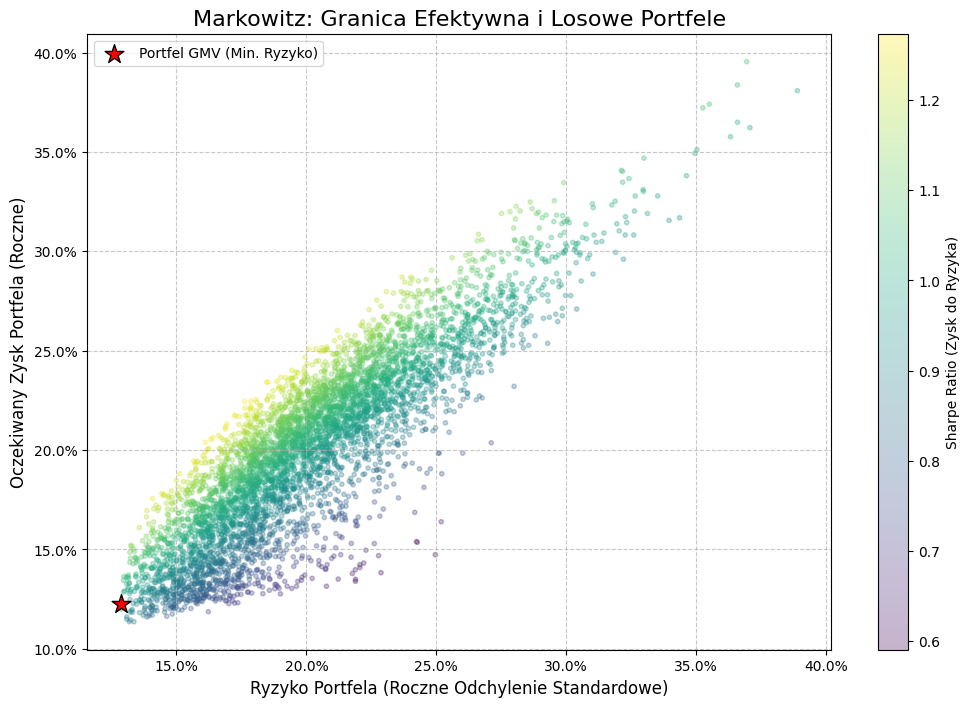

In [11]:
import matplotlib.pyplot as plt

# Przygotowanie parametrów
mu = stocks_returns.mean() * 252
Sigma = stocks_returns.cov() * 252
num_assets = len(stocks_returns.columns)

# Generujemy chmure portfeli
num_portfolios = 5000
results = np.zeros((3, num_portfolios)) # Wiersze: 0=Zysk, 1=Ryzyko, 2=Sharpe Ratio

for i in range(num_portfolios):
    # Losujemy wagi i normalizujemy, żeby sumowały się do 1 (100%)
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    
    # Liczymy zysk i ryzyko (odchylenie standardowe) dla tego losowego portfela
    portfolio_return = np.sum(weights * mu)
    portfolio_std_dev = np.sqrt(weights.T @ Sigma @ weights)
    
    results[0, i] = portfolio_return
    results[1, i] = portfolio_std_dev
    # Zapisujemy tzw. Sharpe Ratio (Zysk / Ryzyko) do pokolorowania kropek
    results[2, i] = portfolio_return / portfolio_std_dev 

# Szukamy GMV
from scipy.optimize import minimize
def min_variance(weights):
    return weights.T @ Sigma @ weights

bounds = tuple((0.0, 1.0) for _ in range(num_assets))
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
init_guess = np.repeat(1/num_assets, num_assets)

opt_gmv = minimize(min_variance, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
gmv_weights = opt_gmv.x
gmv_return = np.sum(gmv_weights * mu)
gmv_std_dev = np.sqrt(gmv_weights.T @ Sigma @ gmv_weights)

# Wykres
plt.figure(figsize=(12, 8))

# Rysujemy chmurę punktów (kolor zależy od stosunku zysku do ryzyka)
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio (Zysk do Ryzyka)')

# Zaznaczamy nasz portfel GMV czerwoną gwiazdką
plt.scatter(gmv_std_dev, gmv_return, marker='*', color='red', s=200, label='Portfel GMV (Min. Ryzyko)', edgecolor='black')

# Formatowanie wykresu
plt.title('Markowitz: Granica Efektywna i Losowe Portfele', fontsize=16)
plt.xlabel('Ryzyko Portfela (Roczne Odchylenie Standardowe)', fontsize=12)
plt.ylabel('Oczekiwany Zysk Portfela (Roczne)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()